# Breast Cancer Detection (BreaKHis 400x)

## Env set up

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

## Device setup

In [3]:
device = (
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: mps


## Data loading and preprocessing

In [4]:
class BreastCancerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.img_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(root_dir))
        for i, c in enumerate(self.classes):
            imgs = glob(os.path.join(root_dir, c, "*.png"))
            self.img_paths.extend(imgs)
            self.labels.extend([i]*len(imgs))
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Model Definitions

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128*28*28, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class VGGInspired(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*28*28, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

class ResNetLike(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(weights=None)
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

## Train code

In [6]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))

        # Validation
        model.eval()
        val_loss, correct = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                val_loss += criterion(out, labels).item()
                correct += (out.argmax(1) == labels).sum().item()
        val_acc = correct / len(val_loader.dataset)
        val_losses.append(val_loss / len(val_loader))
        print(f"Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | Val Acc: {val_acc:.4f}")
    return train_losses, val_losses

## Test code

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

def evaluate_on_testset(model, test_loader, dataset, model_name=None, epoch=None, save=True, save_dir="."):
    model.to(device)
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc="Evaluating"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = (all_preds == all_labels).mean()
    print(f"\n✅ Test Accuracy: {acc:.4f}")

    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=dataset.classes))

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix on Test Set", fontsize=14)
    plt.tight_layout()

    if save and model_name is not None and epoch is not None:
        save_path = os.path.join(save_dir, f"{model_name}_{epoch}")
        os.makedirs(save_path, exist_ok=True)
        out_path = f"{save_path}/confusion_matrix.pdf"
        plt.savefig(out_path, format="pdf", bbox_inches="tight")
        print(f"✅ Saved confusion matrix to {out_path}")
    elif not save:
        print("⚠️ Skipped saving confusion matrix (save=False)")

    plt.show()
    plt.close()

## Grad-CAM

In [8]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.target_layer = target_layer
        self.hook()

    def hook(self):
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]
        def forward_hook(module, input, output):
            self.feature_map = output
        layer = dict(self.model.named_modules())[self.target_layer]
        layer.register_forward_hook(forward_hook)
        layer.register_backward_hook(backward_hook)

    def generate(self, input_img, class_idx=None):
        self.model.zero_grad()
        out = self.model(input_img)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        score = out[:, class_idx]
        score.backward()
        grads = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = (grads * self.feature_map).sum(dim=1).squeeze()
        cam = F.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        cam = cam.cpu().detach().numpy()
        return cam

def show_gradcam(img_tensor, cam):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    if cam.ndim > 2:
        cam = cam[0]

    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    overlay = 0.5 * heatmap + 0.5 * img
    overlay = np.clip(overlay, 0, 1)

    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

def show_gradcam_side_by_side(img_tensor, cam, model, dataset, label_true):
    """
    显示原图与 Grad-CAM 热力图并排，并在标题标注预测与真实标签
    """
    model.eval()
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(device))
        pred_idx = output.argmax(1).item()
    pred_label = dataset.classes[pred_idx]
    true_label = dataset.classes[label_true]

    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    if cam.ndim > 2:
        cam = cam[0]
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    color = "green" if pred_label == true_label else "red"

    axes[0].imshow(img)
    axes[0].set_title("Original", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(heatmap)
    axes[1].set_title("Grad-CAM", fontsize=12)
    axes[1].axis("off")

    fig.suptitle(f"Predicted: {pred_label} | True: {true_label}",
                 color=color, fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()


## Visualization

In [9]:
def plot_curves(train_losses, val_losses, model_name=None, epoch=None, save=True, save_dir="."):
    plt.figure(figsize=(8, 6))
    epochs = np.arange(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label='Training Loss', color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='s', markersize=4)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Training and Validation Loss Curves', fontsize=16, pad=12, weight='bold')
    plt.legend(loc='best', fontsize=12, frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()

    if save and model_name is not None and epoch is not None:
        save_path = os.path.join(save_dir, f"{model_name}_{epoch}")
        os.makedirs(save_path, exist_ok=True)
        out_path = f"{save_path}/loss_curves.pdf"
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        print(f"✅ Saved loss curve to {out_path}")
    elif not save:
        print("⚠️ Skipped saving loss curve (save=False)")

    plt.show()
    plt.close()



def visualize_predictions(model, dataset, num_images=9):
    model.eval()
    indices = np.random.choice(len(dataset), num_images, replace=False)
    n_cols = int(np.ceil(np.sqrt(num_images)))
    n_rows = int(np.ceil(num_images / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.3 * n_cols, 3.3 * n_rows))
    axes = axes.flatten() if num_images > 1 else [axes]

    for ax in axes[num_images:]:
        ax.axis('off')

    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        with torch.no_grad():
            output = model(img.unsqueeze(0).to(device))
            pred = output.argmax(1).item()
        img_np = np.transpose(img.cpu().numpy(), (1, 2, 0))
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)  # normalize to [0,1]

        axes[i].imshow(img_np)
        # Academic professional: show class with full name, pred/true, color highlight for mistakes.
        color = "forestgreen" if pred == label else "crimson"
        axes[i].set_title(
            f"Pred: {dataset.classes[pred]}\nTrue: {dataset.classes[label]}",
            fontsize=11,
            color=color,
            fontweight='bold',
            loc='center'
        )
        axes[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        axes[i].spines['top'].set_color(color)
        axes[i].spines['right'].set_color(color)
        axes[i].spines['left'].set_color(color)
        axes[i].spines['bottom'].set_color(color)
        axes[i].spines['top'].set_linewidth(2 if pred != label else 1)
        axes[i].spines['right'].set_linewidth(2 if pred != label else 1)
        axes[i].spines['left'].set_linewidth(2 if pred != label else 1)
        axes[i].spines['bottom'].set_linewidth(2 if pred != label else 1)
        axes[i].set_xticks([])
        axes[i].set_yticks([])

    plt.suptitle("Model Predictions vs Ground Truth", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Pipeline

In [10]:
data_dir = "./BreaKHis_400X"
train_ds = BreastCancerDataset(os.path.join(data_dir, "train"), train_tfms)
test_ds = BreastCancerDataset(os.path.join(data_dir, "test"), test_tfms)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16)

In [12]:
model_name = 'ResNetLike'
if model_name == 'SimpleCNN':
    model = SimpleCNN(num_classes=2)
elif model_name == 'VGGInspired':
    model = VGGInspired(num_classes=2)
elif model_name == 'ResNetLike':
    model = ResNetLike(num_classes=2)

In [13]:
epoch = 30
train_losses = []
val_losses = []
train_losses, val_losses = train_model(model, train_loader, test_loader, epochs=epoch, lr=1e-4)

Epoch 1/30: 100%|██████████| 72/72 [01:13<00:00,  1.02s/it]


Epoch 1 | Train Loss: 0.4315 | Val Acc: 0.8092


Epoch 2/30: 100%|██████████| 72/72 [01:08<00:00,  1.06it/s]


Epoch 2 | Train Loss: 0.3953 | Val Acc: 0.8440


Epoch 3/30: 100%|██████████| 72/72 [00:50<00:00,  1.44it/s]


...

Epoch 28 | Train Loss: 0.1233 | Val Acc: 0.8917


Epoch 29/30: 100%|██████████| 72/72 [00:43<00:00,  1.64it/s]


Epoch 29 | Train Loss: 0.0967 | Val Acc: 0.8550


Epoch 30/30: 100%|██████████| 72/72 [00:44<00:00,  1.60it/s]


Epoch 30 | Train Loss: 0.1170 | Val Acc: 0.9101


In [14]:
os.makedirs(f"./{model_name}_{epoch}", exist_ok=True)
torch.save(model.state_dict(), f"{model_name}_{epoch}/model.pth")

In [15]:
# read model
if model_name == 'SimpleCNN':
    model = SimpleCNN(num_classes=2)
elif model_name == 'VGGInspired':
    model = VGGInspired(num_classes=2)
elif model_name == 'ResNetLike':
    model = ResNetLike(num_classes=2)
model.load_state_dict(torch.load(f"{model_name}_{epoch}/model.pth", map_location=device))
model.to(device)

ResNetLike(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_ru

✅ Saved loss curve to ./ResNetLike_30/loss_curves.pdf


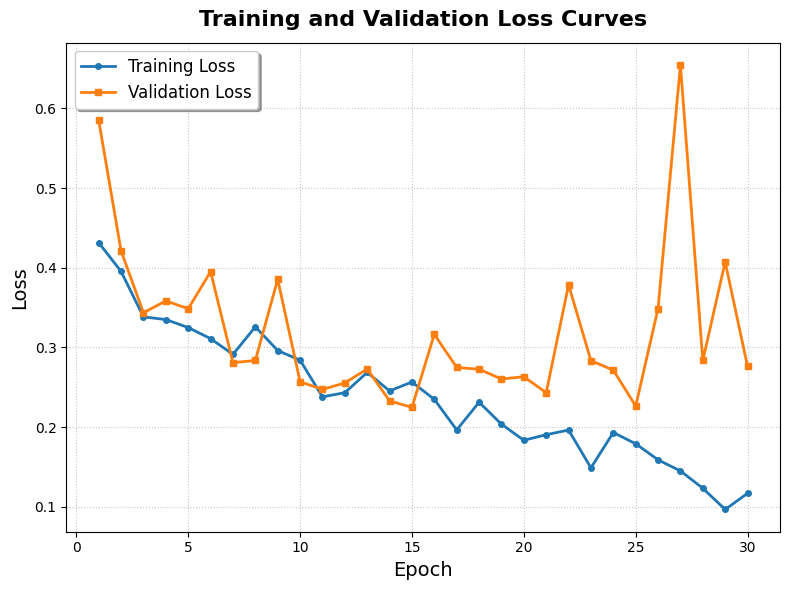

In [16]:
plot_curves(train_losses, val_losses, model_name=model_name, epoch=epoch, save=True)

Evaluating: 100%|██████████| 35/35 [00:11<00:00,  3.02it/s]



✅ Test Accuracy: 0.9101

📊 Classification Report:
              precision    recall  f1-score   support

      benign       0.83      0.91      0.87       176
   malignant       0.96      0.91      0.93       369

    accuracy                           0.91       545
   macro avg       0.89      0.91      0.90       545
weighted avg       0.91      0.91      0.91       545

✅ Saved confusion matrix to ./ResNetLike_30/confusion_matrix.pdf


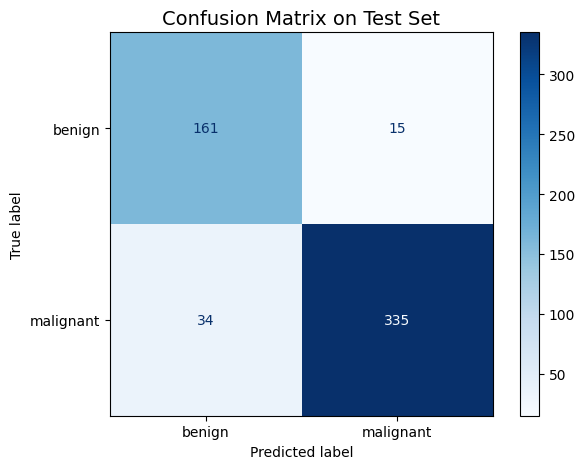

In [17]:
evaluate_on_testset(model, test_loader, test_ds, model_name=model_name, epoch=epoch, save=True)

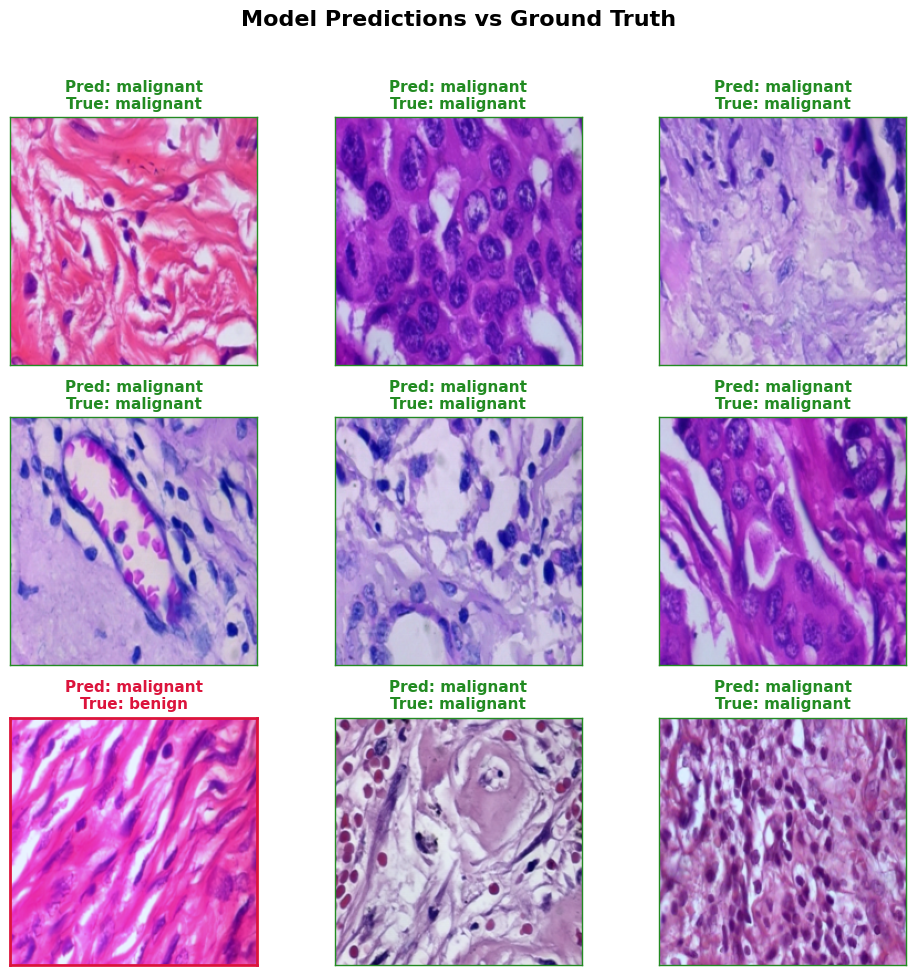

In [18]:
visualize_predictions(model, test_ds, num_images=9)

In [19]:
def get_last_conv_name(model):
    for name, module in reversed(list(model.named_modules())):
        if isinstance(module, torch.nn.Conv2d):
            return name
target_layer = get_last_conv_name(model)
print("Last conv layer:", target_layer)
gradcam = GradCAM(model, target_layer=target_layer)

Last conv layer: model.layer4.1.conv2


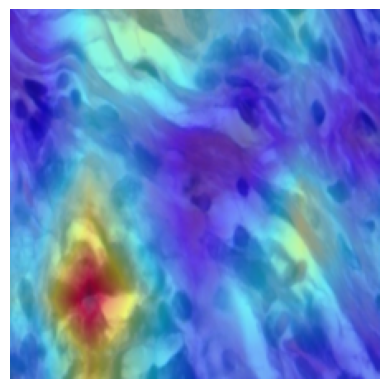

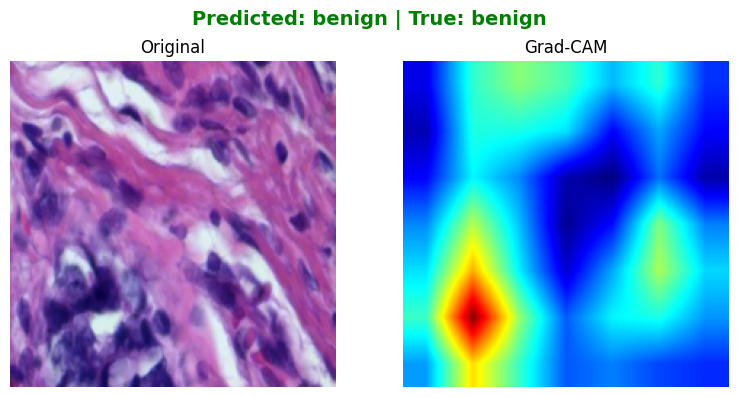

In [27]:
idx = np.random.randint(len(test_ds))
img, label_true = test_ds[idx]
cam = gradcam.generate(img.unsqueeze(0).to(device))
show_gradcam(img, cam)
show_gradcam_side_by_side(img, cam, model, test_ds, label_true)